In [ ]:
# ==================== 第1格：環境、資料路徑與基本檢查 ====================
# 本程式使用1～4月完整30分鐘資料建立「場站供需型態分群」。
# 分群結果只由訓練期資料建立，不使用5月或6月資料。

%pip -q install duckdb scikit-learn seaborn pyarrow

from google.colab import drive, files
drive.mount('/content/drive')

import math
import re
import shutil
import subprocess
import warnings
import zipfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from matplotlib import font_manager
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')


# -------------------- A. 中文字型 --------------------

font_candidates = [
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc'),
]

if not any(path.exists() for path in font_candidates):
    print('安裝中文字型……')
    subprocess.run(
        ['apt-get', '-qq', 'update'],
        check=True,
    )
    subprocess.run(
        ['apt-get', '-qq', 'install', '-y', 'fonts-noto-cjk'],
        check=True,
    )

font_path = next(
    path for path in font_candidates
    if path.exists()
)

font_manager.fontManager.addfont(str(font_path))
chinese_font = font_manager.FontProperties(
    fname=str(font_path)
).get_name()

plt.rcParams['font.family'] = chinese_font
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(
    style='whitegrid',
    font=chinese_font,
)


# -------------------- B. 路徑設定 --------------------

DRIVE_ROOT = Path('/content/drive/MyDrive')
HACKATHON_DIR = DRIVE_ROOT / 'Hackathon_Data'
ZIP_NAME = '訓練集2_一到四月.zip'

WORK_DIR = Path('/content/kmeans_30_60_work')
RESULT_DIR = Path('/content/KMeans_供需分群結果')
DUCKDB_TEMP_DIR = Path('/content/duckdb_temp')

for folder in [WORK_DIR, RESULT_DIR, DUCKDB_TEMP_DIR]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)


def find_input_zip():
    direct_path = HACKATHON_DIR / ZIP_NAME

    if direct_path.exists():
        return direct_path

    matches = list(DRIVE_ROOT.rglob(ZIP_NAME))

    if matches:
        return matches[0]

    raise FileNotFoundError(
        f'找不到Hackathon_Data/{ZIP_NAME}。\n'
        '請確認ZIP已放入Google Drive。'
    )


ZIP_PATH = find_input_zip()

print('輸入資料：', ZIP_PATH)
print('結果只會建立在Colab /content，不會備份到Drive。')


# -------------------- C. 解壓縮 --------------------

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(WORK_DIR)

CSV_FILES = sorted(
    path
    for path in WORK_DIR.rglob('*.csv')
    if '__MACOSX' not in path.parts
    and not path.name.startswith('._')
)

if len(CSV_FILES) != 4:
    raise RuntimeError(
        f'預期有1～4月共4個CSV，實際找到{len(CSV_FILES)}個。'
    )

print('\n找到四個月份：')
for path in CSV_FILES:
    print(' -', path.relative_to(WORK_DIR))


def detect_encoding(path):
    for encoding in ['utf-8-sig', 'utf-8', 'cp950', 'big5']:
        try:
            pd.read_csv(
                path,
                encoding=encoding,
                nrows=5,
                low_memory=False,
            )
            return encoding
        except UnicodeDecodeError:
            continue

    raise ValueError(f'無法判斷編碼：{path.name}')


REQUIRED_COLUMNS = [
    '日期',
    '城市',
    '行政區',
    '場站名稱',
    '總車柱數',
    '可借車數',
    '可還位數',
    '經度',
    '緯度',
    '日曆',
    '場站',
    '資料品質標記',
    '異常原因',
]

for csv_path in CSV_FILES:
    encoding = detect_encoding(csv_path)

    header = pd.read_csv(
        csv_path,
        encoding=encoding,
        nrows=0,
    )

    missing = [
        column
        for column in REQUIRED_COLUMNS
        if column not in header.columns
    ]

    if missing:
        raise ValueError(
            f'{csv_path.name}缺少欄位：{missing}'
        )

print('\n第1格完成：四個CSV欄位檢查通過。')


Mounted at /content/drive
安裝中文字型……
輸入資料： /content/drive/MyDrive/Hackathon_Data/訓練集2_一到四月.zip
結果只會建立在Colab /content，不會備份到Drive。

找到四個月份：
 - 訓練集2_一到四月/training_data_01月_完整時段_日曆場站.csv
 - 訓練集2_一到四月/training_data_02月_完整時段_日曆場站.csv
 - 訓練集2_一到四月/training_data_03月_完整時段_日曆場站.csv
 - 訓練集2_一到四月/training_data_04月_完整時段_日曆場站.csv

第1格完成：四個CSV欄位檢查通過。


In [ ]:
# ==================== 第2格：建立30／60分鐘場站行為特徵 ====================
# 使用DuckDB處理大型CSV，避免一次把八百多萬筆資料載入記憶體。
# 異常資料不參與分群特徵，但第5格輸出時仍會保留原始資料。

DB_PATH = Path('/content/kmeans_30_60.duckdb')

if DB_PATH.exists():
    DB_PATH.unlink()

con = duckdb.connect(str(DB_PATH))

con.execute("PRAGMA threads=4")
con.execute("PRAGMA memory_limit='6GB'")
con.execute(
    f"PRAGMA temp_directory='{str(DUCKDB_TEMP_DIR)}'"
)

csv_sql_list = '[' + ','.join(
    "'" + str(path).replace("'", "''") + "'"
    for path in CSV_FILES
) + ']'


# -------------------- A. 讀取四個月CSV --------------------

con.execute(f'''
CREATE OR REPLACE VIEW raw_data AS
SELECT *
FROM read_csv(
    {csv_sql_list},
    header=true,
    union_by_name=true,
    all_varchar=true,
    auto_detect=true
)
''')

raw_count = con.execute(
    'SELECT COUNT(*) FROM raw_data'
).fetchone()[0]

print(f'原始總筆數：{raw_count:,}')


# -------------------- B. 清理並建立時間落後特徵 --------------------

print('建立30／60分鐘變化特徵，這一步需要數分鐘……')

con.execute('''
CREATE OR REPLACE TABLE signal_data AS
WITH typed AS (
    SELECT
        COALESCE(
            TRY_STRPTIME("日期", '%Y-%m-%d %H:%M:%S'),
            TRY_CAST("日期" AS TIMESTAMP)
        ) AS "日期",
        TRIM(COALESCE("城市", '新北市')) AS "城市",
        TRIM(COALESCE("行政區", '')) AS "行政區",
        TRIM(COALESCE("場站名稱", '')) AS "場站名稱",
        TRY_CAST("總車柱數" AS DOUBLE) AS "總車柱數",
        TRY_CAST("可借車數" AS DOUBLE) AS "可借車數",
        TRY_CAST("可還位數" AS DOUBLE) AS "可還位數",
        TRY_CAST("經度" AS DOUBLE) AS "經度",
        TRY_CAST("緯度" AS DOUBLE) AS "緯度",
        TRIM(COALESCE("日曆", '')) AS "日曆",
        TRIM(COALESCE("場站", '')) AS "場站",
        TRIM(COALESCE("資料品質標記", '正常')) AS "資料品質標記"
    FROM raw_data
),
valid AS (
    SELECT *
    FROM typed
    WHERE "日期" IS NOT NULL
      AND "場站名稱" <> ''
      AND "總車柱數" > 0
      AND "可借車數" BETWEEN 0 AND "總車柱數"
      AND "可還位數" BETWEEN 0 AND "總車柱數"
      AND COALESCE(NULLIF("資料品質標記", ''), '正常') = '正常'
),
deduplicated AS (
    SELECT * EXCLUDE (row_number_in_time)
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY
                    "城市", "行政區", "場站名稱", "日期"
                ORDER BY "日期"
            ) AS row_number_in_time
        FROM valid
    )
    WHERE row_number_in_time = 1
),
lagged AS (
    SELECT
        *,
        LAG("日期", 1) OVER station_time AS previous_time_30,
        LAG("日期", 2) OVER station_time AS previous_time_60,
        LAG("可借車數", 1) OVER station_time AS previous_bikes_30,
        LAG("可借車數", 2) OVER station_time AS previous_bikes_60,
        LAG("可還位數", 1) OVER station_time AS previous_docks_30,
        LAG("可還位數", 2) OVER station_time AS previous_docks_60
    FROM deduplicated
    WINDOW station_time AS (
        PARTITION BY "城市", "行政區", "場站名稱"
        ORDER BY "日期"
    )
)
SELECT
    "日期",
    "城市",
    "行政區",
    "場站名稱",
    "總車柱數",
    "可借車數",
    "可還位數",
    "經度",
    "緯度",
    "日曆",
    "場站",

    "可借車數" / "總車柱數" AS "可借車比例",
    "可還位數" / "總車柱數" AS "可還位比例",
    GREATEST(
        "總車柱數" - "可借車數" - "可還位數",
        0
    ) / "總車柱數" AS "不可用柱比例",

    CASE
        WHEN DATE_DIFF('minute', previous_time_30, "日期") = 30
        THEN "可借車數" - previous_bikes_30
        ELSE NULL
    END AS "可借變化30",

    CASE
        WHEN DATE_DIFF('minute', previous_time_60, "日期") = 60
        THEN "可借車數" - previous_bikes_60
        ELSE NULL
    END AS "可借變化60",

    CASE
        WHEN DATE_DIFF('minute', previous_time_30, "日期") = 30
        THEN "可還位數" - previous_docks_30
        ELSE NULL
    END AS "可還位變化30",

    CASE
        WHEN DATE_DIFF('minute', previous_time_60, "日期") = 60
        THEN "可還位數" - previous_docks_60
        ELSE NULL
    END AS "可還位變化60",

    CASE
        WHEN DATE_DIFF('minute', previous_time_30, "日期") = 30
        THEN ("可借車數" - previous_bikes_30) / "總車柱數"
        ELSE NULL
    END AS "可借變化30比例",

    CASE
        WHEN DATE_DIFF('minute', previous_time_60, "日期") = 60
        THEN ("可借車數" - previous_bikes_60) / "總車柱數"
        ELSE NULL
    END AS "可借變化60比例",

    CASE
        WHEN EXTRACT(hour FROM "日期") BETWEEN 6 AND 9
            THEN '早高峰'
        WHEN EXTRACT(hour FROM "日期") BETWEEN 10 AND 15
            THEN '日間'
        WHEN EXTRACT(hour FROM "日期") BETWEEN 16 AND 19
            THEN '晚高峰'
        WHEN EXTRACT(hour FROM "日期") BETWEEN 20 AND 23
            THEN '夜間'
        ELSE '深夜'
    END AS "時段",

    CASE WHEN CONTAINS("場站", '捷運站') THEN 1 ELSE 0 END AS "是否捷運站",
    CASE WHEN CONTAINS("場站", '火車站') THEN 1 ELSE 0 END AS "是否火車站",
    CASE WHEN CONTAINS("場站", '公車站') THEN 1 ELSE 0 END AS "是否公車站",
    CASE WHEN CONTAINS("場站", '學校') THEN 1 ELSE 0 END AS "是否學校",
    CASE WHEN CONTAINS("場站", '公園') THEN 1 ELSE 0 END AS "是否公園",
    CASE WHEN CONTAINS("場站", '商圈') THEN 1 ELSE 0 END AS "是否商圈",
    CASE WHEN CONTAINS("場站", '醫院') THEN 1 ELSE 0 END AS "是否醫院"
FROM lagged
''')

valid_count = con.execute(
    'SELECT COUNT(*) FROM signal_data'
).fetchone()[0]

print(f'用於分群特徵的正常有效資料：{valid_count:,}筆')
print(f'未參與特徵計算：{raw_count - valid_count:,}筆')


# -------------------- C. 每日行為摘要 --------------------

con.execute('''
CREATE OR REPLACE TABLE station_daily AS
SELECT
    "城市",
    "行政區",
    "場站名稱",
    CAST("日期" AS DATE) AS calendar_date,
    MAX("可借車比例") - MIN("可借車比例") AS daily_bike_range
FROM signal_data
GROUP BY
    "城市", "行政區", "場站名稱", CAST("日期" AS DATE)
''')


# -------------------- D. 每個場站濃縮成一列 --------------------

station_features = con.execute('''
WITH daily_summary AS (
    SELECT
        "城市",
        "行政區",
        "場站名稱",
        AVG(daily_bike_range) AS "平均每日可借比例範圍"
    FROM station_daily
    GROUP BY "城市", "行政區", "場站名稱"
),
station_summary AS (
    SELECT
        "城市",
        "行政區",
        "場站名稱",
        MEDIAN("總車柱數") AS "總車柱數中位數",
        AVG("經度") AS "經度",
        AVG("緯度") AS "緯度",
        MAX("場站") AS "場站類型原文",
        COUNT(*) AS "有效觀測筆數",
        COUNT(DISTINCT CAST("日期" AS DATE)) AS "資料涵蓋日數",
        MIN("日期") AS "資料起始時間",
        MAX("日期") AS "資料結束時間",

        AVG("可借車比例") AS "平均可借比例",
        STDDEV_SAMP("可借車比例") AS "可借比例標準差",
        AVG("可還位比例") AS "平均可還位比例",
        STDDEV_SAMP("可還位比例") AS "可還位比例標準差",
        AVG("不可用柱比例") AS "平均不可用柱比例",

        AVG(ABS("可借變化30比例")) AS "平均活動強度30",
        STDDEV_SAMP(ABS("可借變化30比例")) AS "活動強度30標準差",
        AVG(ABS("可借變化60比例")) AS "平均活動強度60",
        AVG(CASE WHEN "可借變化30比例" IS NOT NULL THEN 1.0 ELSE 0.0 END)
            AS "30分鐘連續資料率",
        AVG(CASE WHEN "可借變化60比例" IS NOT NULL THEN 1.0 ELSE 0.0 END)
            AS "60分鐘連續資料率",

        AVG(CASE WHEN "時段" = '早高峰' THEN "可借變化30比例" END)
            AS "早高峰淨變化30比例",
        AVG(CASE WHEN "時段" = '日間' THEN "可借變化30比例" END)
            AS "日間淨變化30比例",
        AVG(CASE WHEN "時段" = '晚高峰' THEN "可借變化30比例" END)
            AS "晚高峰淨變化30比例",
        AVG(CASE WHEN "時段" = '夜間' THEN "可借變化30比例" END)
            AS "夜間淨變化30比例",

        AVG(CASE WHEN "時段" = '早高峰' THEN ABS("可借變化30比例") END)
            AS "早高峰活動強度",
        AVG(CASE WHEN "時段" = '日間' THEN ABS("可借變化30比例") END)
            AS "日間活動強度",
        AVG(CASE WHEN "時段" = '晚高峰' THEN ABS("可借變化30比例") END)
            AS "晚高峰活動強度",
        AVG(CASE WHEN "時段" = '夜間' THEN ABS("可借變化30比例") END)
            AS "夜間活動強度",

        AVG(CASE WHEN "可借車比例" <= 0.05 THEN 1.0 ELSE 0.0 END)
            AS "缺車率5",
        AVG(CASE WHEN "可還位比例" <= 0.05 THEN 1.0 ELSE 0.0 END)
            AS "滿車率5",
        AVG(CASE WHEN "可借車比例" <= 0.10 THEN 1.0 ELSE 0.0 END)
            AS "低車率10",
        AVG(CASE WHEN "可還位比例" <= 0.10 THEN 1.0 ELSE 0.0 END)
            AS "低空位率10",

        AVG(CASE
            WHEN "時段" = '早高峰' AND "可借車比例" <= 0.10
            THEN 1.0
            WHEN "時段" = '早高峰' THEN 0.0
        END) AS "早高峰缺車率",

        AVG(CASE
            WHEN "時段" = '晚高峰' AND "可借車比例" <= 0.10
            THEN 1.0
            WHEN "時段" = '晚高峰' THEN 0.0
        END) AS "晚高峰缺車率",

        AVG(CASE
            WHEN "時段" = '早高峰' AND "可還位比例" <= 0.10
            THEN 1.0
            WHEN "時段" = '早高峰' THEN 0.0
        END) AS "早高峰滿車率",

        AVG(CASE
            WHEN "時段" = '晚高峰' AND "可還位比例" <= 0.10
            THEN 1.0
            WHEN "時段" = '晚高峰' THEN 0.0
        END) AS "晚高峰滿車率",

        AVG(CASE WHEN "日曆" = '平日' THEN ABS("可借變化30比例") END)
            AS "平日活動強度",
        AVG(CASE WHEN "日曆" = '假日' THEN ABS("可借變化30比例") END)
            AS "假日活動強度",
        AVG(CASE WHEN "日曆" = '國定假日' THEN ABS("可借變化30比例") END)
            AS "國定假日活動強度",
        AVG(CASE WHEN "日曆" = '平日' THEN "可借車比例" END)
            AS "平日平均可借比例",
        AVG(CASE WHEN "日曆" IN ('假日', '國定假日') THEN "可借車比例" END)
            AS "假日平均可借比例",

        MAX("是否捷運站") AS "是否捷運站",
        MAX("是否火車站") AS "是否火車站",
        MAX("是否公車站") AS "是否公車站",
        MAX("是否學校") AS "是否學校",
        MAX("是否公園") AS "是否公園",
        MAX("是否商圈") AS "是否商圈",
        MAX("是否醫院") AS "是否醫院"

    FROM signal_data
    GROUP BY "城市", "行政區", "場站名稱"
)
SELECT
    station_summary.*,
    daily_summary."平均每日可借比例範圍"
FROM station_summary
LEFT JOIN daily_summary
USING ("城市", "行政區", "場站名稱")
ORDER BY "城市", "行政區", "場站名稱"
''').df()

station_features['假日相對平日活動差'] = (
    station_features['假日活動強度']
    - station_features['平日活動強度']
)

station_features['假日相對平日可借比例差'] = (
    station_features['假日平均可借比例']
    - station_features['平日平均可借比例']
)

STATION_FEATURE_PARQUET = (
    RESULT_DIR / '場站供需特徵_分群前.parquet'
)

station_features.to_parquet(
    STATION_FEATURE_PARQUET,
    index=False,
)

print(
    f'\n場站特徵建立完成：'
    f'{len(station_features):,}個場站'
)

display(station_features.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

原始總筆數：8,787,329
建立30／60分鐘變化特徵，這一步需要數分鐘……


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

用於分群特徵的正常有效資料：8,777,910筆
未參與特徵計算：9,419筆


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


場站特徵建立完成：1,540個場站


,城市,行政區,場站名稱,總車柱數中位數,經度,緯度,場站類型原文,有效觀測筆數,資料涵蓋日數,資料起始時間,...,是否捷運站,是否火車站,是否公車站,是否學校,是否公園,是否商圈,是否醫院,平均每日可借比例範圍,假日相對平日活動差,假日相對平日可借比例差
0,新北市,三峽區,三峽中山公園,15.0,121.36584,24.93561,"公車站,學校,公園,醫院",5757,120,2026-01-01,...,0,0,1,1,1,0,1,0.370556,0.006585,-0.019068
1,新北市,三峽區,三峽區公所(三峽老街),33.0,121.36929,24.93390,"公車站,學校,公園,商圈",5757,120,2026-01-01,...,0,0,1,1,1,1,0,0.517929,0.024969,0.053810
2,新北市,三峽區,三峽區礁溪行政中心,20.0,121.37592,24.92843,"公車站,學校,公園",5757,120,2026-01-01,...,0,0,1,1,1,0,0,0.539167,0.006170,-0.010758
3,新北市,三峽區,三峽原住民族生活文化園區,31.0,121.36672,24.94565,"學校,公園",5757,120,2026-01-01,...,0,0,0,1,1,0,0,0.131183,-0.000286,-0.043827
4,新北市,三峽區,三峽國中,33.0,121.36900,24.93890,"捷運站,公車站,學校,公園",5757,120,2026-01-01,...,1,0,1,1,1,0,0,0.596465,-0.024695,0.042325


In [ ]:
# ==================== 第3格：比較K=4～8並執行K-Means ====================
# K一定大於3。
# 評估同時考慮分離度、群內緊密度、不同初始化的穩定性與群大小平衡。

FEATURE_GROUPS = {
    '容量': [
        '總車柱數中位數',
    ],
    '整體供需': [
        '平均可借比例',
        '可借比例標準差',
        '平均可還位比例',
        '可還位比例標準差',
        '平均不可用柱比例',
        '平均每日可借比例範圍',
        '平均活動強度30',
        '活動強度30標準差',
        '平均活動強度60',
    ],
    '尖峰型態': [
        '早高峰淨變化30比例',
        '日間淨變化30比例',
        '晚高峰淨變化30比例',
        '夜間淨變化30比例',
        '早高峰活動強度',
        '日間活動強度',
        '晚高峰活動強度',
        '夜間活動強度',
    ],
    '風險': [
        '缺車率5',
        '滿車率5',
        '低車率10',
        '低空位率10',
        '早高峰缺車率',
        '晚高峰缺車率',
        '早高峰滿車率',
        '晚高峰滿車率',
    ],
    '日曆差異': [
        '平日活動強度',
        '假日活動強度',
        '國定假日活動強度',
        '假日相對平日活動差',
        '假日相對平日可借比例差',
    ],
    '場站環境': [
        '是否捷運站',
        '是否火車站',
        '是否公車站',
        '是否學校',
        '是否公園',
        '是否商圈',
        '是否醫院',
    ],
}

# 群組權重而不是單一欄位權重。
# 尖峰行為和風險稍高；場站環境只用來輔助解釋，不讓它主導結果。
GROUP_WEIGHTS = {
    '容量': 0.55,
    '整體供需': 1.00,
    '尖峰型態': 1.20,
    '風險': 1.10,
    '日曆差異': 0.85,
    '場站環境': 0.65,
}

all_requested_features = [
    feature
    for features in FEATURE_GROUPS.values()
    for feature in features
]

missing_features = [
    feature
    for feature in all_requested_features
    if feature not in station_features.columns
]

if missing_features:
    raise ValueError(
        f'缺少分群特徵：{missing_features}'
    )

model_frame = station_features[
    all_requested_features
].apply(
    pd.to_numeric,
    errors='coerce',
)

# 全空欄位填0，其餘以中位數補值。
for column in model_frame.columns:
    if model_frame[column].notna().sum() == 0:
        model_frame[column] = 0.0
    else:
        model_frame[column] = model_frame[column].fillna(
            model_frame[column].median()
        )

# 場站類型是0/1，不做截尾；連續變數以1%及99%截尾降低異常值影響。
station_type_features = FEATURE_GROUPS['場站環境']

for column in model_frame.columns:
    if column in station_type_features:
        continue

    lower = model_frame[column].quantile(0.01)
    upper = model_frame[column].quantile(0.99)

    model_frame[column] = model_frame[column].clip(
        lower=lower,
        upper=upper,
    )

# 移除沒有變化的欄位，避免無資訊特徵干擾。
usable_features = [
    column
    for column in model_frame.columns
    if model_frame[column].nunique(dropna=False) > 1
    and float(model_frame[column].std()) > 1e-10
]

removed_features = sorted(
    set(model_frame.columns) - set(usable_features)
)

if removed_features:
    print('沒有變化、已排除的特徵：', removed_features)

model_frame = model_frame[usable_features].copy()

scaler = StandardScaler()
X_standard = scaler.fit_transform(model_frame)
X_weighted = X_standard.copy()

# 每組的總影響量依GROUP_WEIGHTS控制，避免欄位較多的群組自然占優勢。
for group_name, group_features in FEATURE_GROUPS.items():
    active_features = [
        feature
        for feature in group_features
        if feature in usable_features
    ]

    if not active_features:
        continue

    group_factor = (
        GROUP_WEIGHTS[group_name]
        / math.sqrt(len(active_features))
    )

    for feature in active_features:
        feature_index = usable_features.index(feature)
        X_weighted[:, feature_index] *= group_factor


# -------------------- A. 比較K值 --------------------

K_VALUES = list(range(4, 9))
evaluation_records = []
base_labels_by_k = {}

minimum_cluster_size = max(
    25,
    int(len(station_features) * 0.02),
)

print(
    f'開始比較K={K_VALUES}，'
    f'每群至少希望有{minimum_cluster_size}站。'
)

for k in K_VALUES:
    base_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50,
        max_iter=500,
        algorithm='lloyd',
    )

    labels = base_model.fit_predict(X_weighted)
    base_labels_by_k[k] = labels

    cluster_sizes = pd.Series(labels).value_counts()

    seed_stabilities = []
    for seed in [11, 22, 33, 44, 55]:
        repeat_labels = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=20,
            max_iter=500,
            algorithm='lloyd',
        ).fit_predict(X_weighted)

        seed_stabilities.append(
            adjusted_rand_score(
                labels,
                repeat_labels,
            )
        )

    evaluation_records.append({
        'K值': k,
        'Silhouette': silhouette_score(
            X_weighted,
            labels,
        ),
        'Davies-Bouldin': davies_bouldin_score(
            X_weighted,
            labels,
        ),
        'Calinski-Harabasz': calinski_harabasz_score(
            X_weighted,
            labels,
        ),
        '初始化穩定性ARI': float(
            np.mean(seed_stabilities)
        ),
        '最小群站數': int(cluster_sizes.min()),
        '最大群站數': int(cluster_sizes.max()),
        '最小群比例': float(
            cluster_sizes.min()
            / len(station_features)
        ),
        '符合群大小條件': bool(
            cluster_sizes.min()
            >= minimum_cluster_size
        ),
    })

k_evaluation = pd.DataFrame(evaluation_records)

# 將不同方向的指標都轉成0～1排名。
k_evaluation['Silhouette排名'] = (
    k_evaluation['Silhouette'].rank(pct=True)
)

k_evaluation['Davies-Bouldin排名'] = (
    (-k_evaluation['Davies-Bouldin']).rank(pct=True)
)

k_evaluation['Calinski-Harabasz排名'] = (
    k_evaluation['Calinski-Harabasz'].rank(pct=True)
)

k_evaluation['穩定性排名'] = (
    k_evaluation['初始化穩定性ARI'].rank(pct=True)
)

k_evaluation['群大小平衡排名'] = (
    k_evaluation['最小群比例'].rank(pct=True)
)

k_evaluation['綜合分數'] = (
    0.35 * k_evaluation['Silhouette排名']
    + 0.20 * k_evaluation['Davies-Bouldin排名']
    + 0.15 * k_evaluation['Calinski-Harabasz排名']
    + 0.20 * k_evaluation['穩定性排名']
    + 0.10 * k_evaluation['群大小平衡排名']
)

valid_k = k_evaluation.loc[
    k_evaluation['符合群大小條件']
].copy()

if valid_k.empty:
    print(
        '警告：沒有K值完全符合最小群大小條件，'
        '改由全部K值中選綜合分數最高者。'
    )
    selection_pool = k_evaluation
else:
    selection_pool = valid_k

BEST_K = int(
    selection_pool.sort_values(
        ['綜合分數', 'Silhouette', '初始化穩定性ARI'],
        ascending=False,
    ).iloc[0]['K值']
)

if BEST_K <= 3:
    raise RuntimeError('K值必須大於3。')

print(f'\n依綜合評估選擇K={BEST_K}')

display(
    k_evaluation.sort_values('K值').round(4)
)


# -------------------- B. 最終K-Means --------------------

final_model = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=100,
    max_iter=1000,
    algorithm='lloyd',
)

cluster_codes = final_model.fit_predict(X_weighted)

station_features['分群代碼_內部'] = cluster_codes

cluster_size_check = (
    station_features['分群代碼_內部']
    .value_counts()
    .sort_index()
)

print('\n各群場站數：')
display(
    cluster_size_check
    .rename_axis('內部分群代碼')
    .reset_index(name='場站數')
)

print('\n第3格完成。下一格會依各群真正的供需特徵產生中文名稱。')


開始比較K=[4, 5, 6, 7, 8]，每群至少希望有30站。

依綜合評估選擇K=4


,K值,Silhouette,Davies-Bouldin,Calinski-Harabasz,初始化穩定性ARI,最小群站數,最大群站數,最小群比例,符合群大小條件,Silhouette排名,Davies-Bouldin排名,Calinski-Harabasz排名,穩定性排名,群大小平衡排名,綜合分數
0,4,0.1936,1.5757,400.3226,0.9967,41,617,0.0266,True,1.0,0.6,1.0,0.8,0.6,0.84
1,5,0.1760,1.5148,373.9391,0.9993,41,551,0.0266,True,0.6,0.8,0.8,1.0,0.6,0.75
2,6,0.1781,1.4707,346.3401,0.9730,41,503,0.0266,True,0.8,1.0,0.6,0.6,0.6,0.75
3,7,0.1720,1.5834,316.6286,0.9123,41,479,0.0266,True,0.4,0.4,0.4,0.2,0.6,0.38
4,8,0.1417,1.7023,292.7719,0.9625,41,351,0.0266,True,0.2,0.2,0.2,0.4,0.6,0.28



各群場站數：


,內部分群代碼,場站數
0,0,424
1,1,618
2,2,457
3,3,41



第3格完成。下一格會依各群真正的供需特徵產生中文名稱。


K=4，中文分群名稱如下：


,分群,場站數,場站占比,命名依據,平均總車柱數,平均可借比例,平均活動強度30,平均活動強度60,早高峰淨變化,晚高峰淨變化,假日活動差,缺車率,滿車率,捷運站比例,火車站比例,公車站比例,學校比例,公園比例,商圈比例,醫院比例
1,平穩低波動型,618,0.4013,低車風險偏低、早高峰缺車風險偏低、晚高峰缺車風險偏低、60分鐘活動強度偏低、早高峰活動偏低、...,23.4612,0.4001,0.0263,0.0436,-0.0032,-0.0003,0.0009,0.0915,0.0140,0.1715,0.0146,0.9353,0.5858,0.8188,0.1570,0.1926
2,均衡流動型,457,0.2968,場站容量偏高、平均可借車比例偏低、低車風險偏高、晚高峰缺車風險偏高、早高峰缺車風險偏高、嚴重...,45.4573,0.2962,0.0342,0.0565,-0.0063,0.0007,-0.0032,0.2669,0.0111,0.2757,0.0525,0.9912,0.7199,0.9147,0.4158,0.4661
0,醫院周邊－雙尖峰高流動型,424,0.2753,30分鐘活動強度偏高、60分鐘活動強度偏高、平日活動偏高、活動波動偏高、假日活動偏高、夜間活動偏高,21.7193,0.3879,0.0739,0.1123,-0.0149,0.0034,-0.0018,0.1870,0.0478,0.2736,0.0165,0.9882,0.7075,0.9033,0.4033,0.5236
3,火車站周邊－通勤到達型－高滿車風險,41,0.0266,嚴重滿車風險偏高、低空位風險偏高、晚高峰滿車風險偏高、嚴重缺車風險偏高、低車風險偏高、平均可...,27.2439,0.1329,0.0149,0.0279,0.0325,-0.0290,0.0025,0.6208,0.5183,0.0244,0.1951,0.9024,0.3902,0.5854,0.2195,0.2683


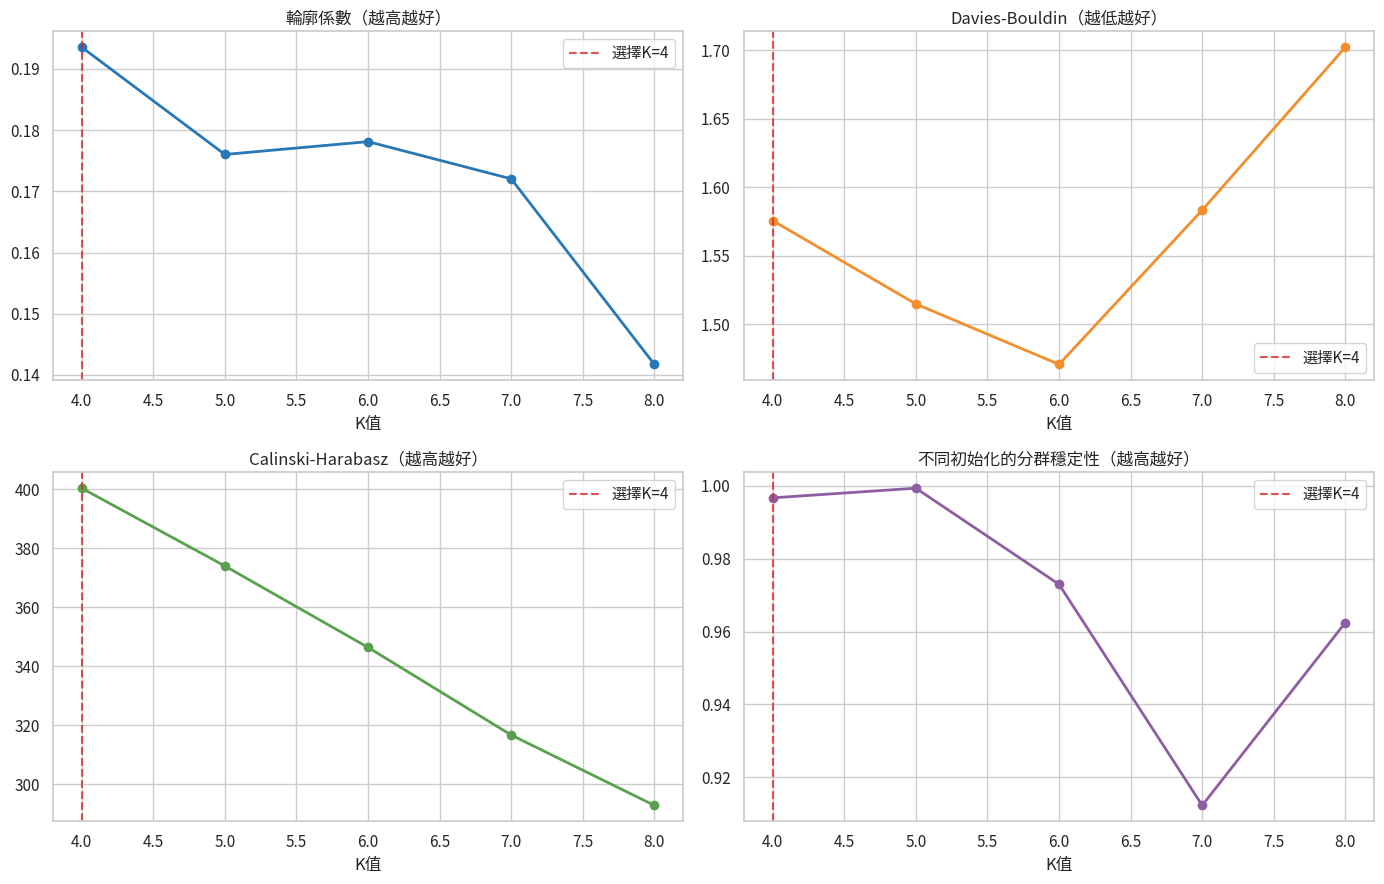

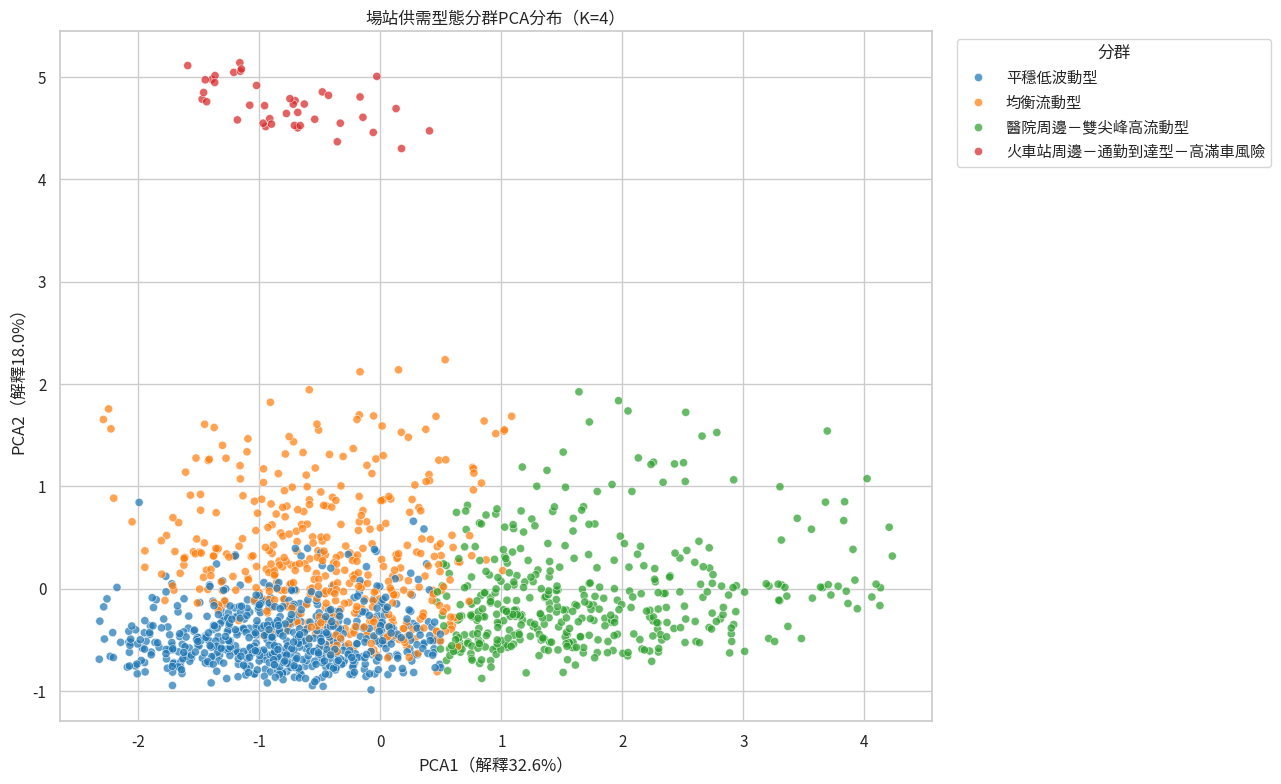

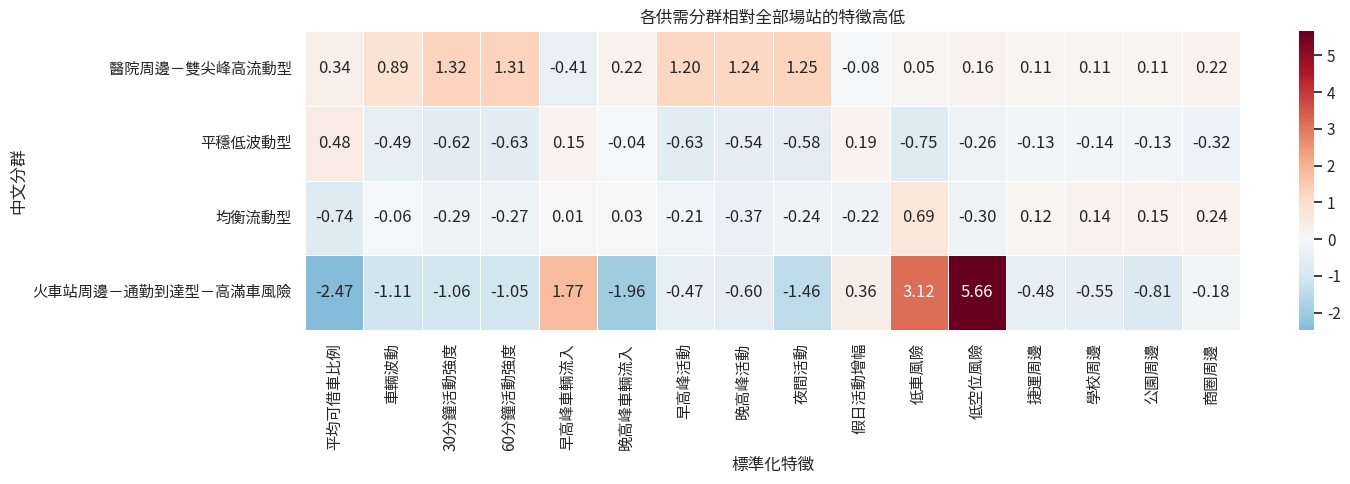

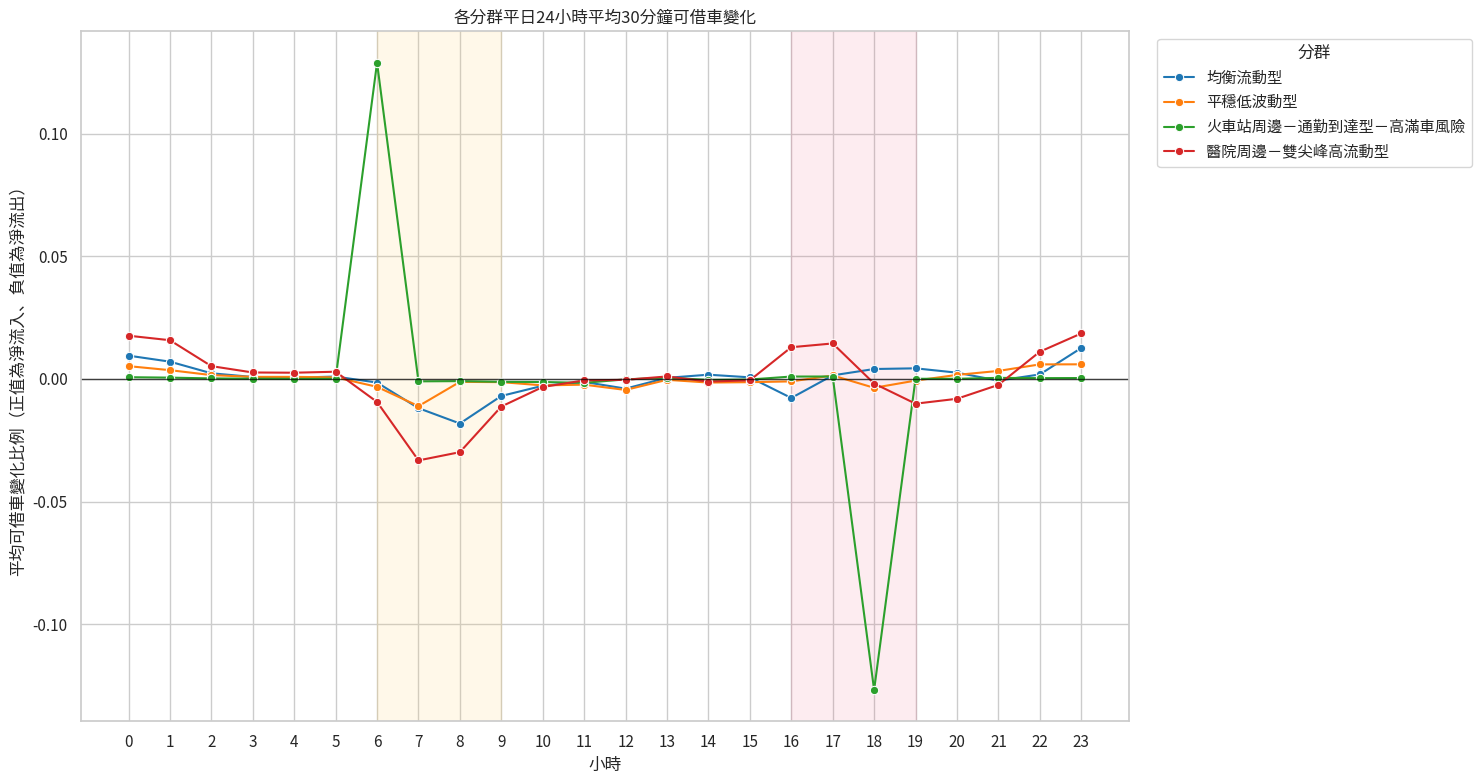


第4格完成：中文命名及可視化已建立。


In [ ]:
# ==================== 第4格：中文命名、關聯摘要與可視化 ====================
# 中文名稱由各群的尖峰方向、活動強度、風險及場站環境共同決定。
# 不會只輸出「群組1、群組2」。

z_frame = pd.DataFrame(
    X_standard,
    columns=usable_features,
    index=station_features.index,
)

z_frame['分群代碼_內部'] = (
    station_features['分群代碼_內部'].to_numpy()
)

cluster_z = z_frame.groupby(
    '分群代碼_內部'
).mean()

numeric_profile = (
    station_features
    .groupby('分群代碼_內部')
    .mean(numeric_only=True)
)

FEATURE_LABELS = {
    '總車柱數中位數': '場站容量',
    '平均可借比例': '平均可借車比例',
    '可借比例標準差': '車輛波動',
    '平均每日可借比例範圍': '每日供需變動',
    '平均活動強度30': '30分鐘活動強度',
    '活動強度30標準差': '活動波動',
    '平均活動強度60': '60分鐘活動強度',
    '早高峰淨變化30比例': '早高峰車輛流入',
    '日間淨變化30比例': '日間車輛流入',
    '晚高峰淨變化30比例': '晚高峰車輛流入',
    '夜間淨變化30比例': '夜間車輛流入',
    '早高峰活動強度': '早高峰活動',
    '日間活動強度': '日間活動',
    '晚高峰活動強度': '晚高峰活動',
    '夜間活動強度': '夜間活動',
    '缺車率5': '嚴重缺車風險',
    '滿車率5': '嚴重滿車風險',
    '低車率10': '低車風險',
    '低空位率10': '低空位風險',
    '早高峰缺車率': '早高峰缺車風險',
    '晚高峰缺車率': '晚高峰缺車風險',
    '早高峰滿車率': '早高峰滿車風險',
    '晚高峰滿車率': '晚高峰滿車風險',
    '平日活動強度': '平日活動',
    '假日活動強度': '假日活動',
    '國定假日活動強度': '國定假日活動',
    '假日相對平日活動差': '假日活動增幅',
    '假日相對平日可借比例差': '假日可借車增幅',
    '是否捷運站': '捷運周邊',
    '是否火車站': '火車站周邊',
    '是否公車站': '公車站周邊',
    '是否學校': '學校周邊',
    '是否公園': '公園周邊',
    '是否商圈': '商圈周邊',
    '是否醫院': '醫院周邊',
}

TYPE_CONTEXTS = [
    ('是否捷運站', '捷運周邊'),
    ('是否火車站', '火車站周邊'),
    ('是否公車站', '公車站周邊'),
    ('是否學校', '學校周邊'),
    ('是否公園', '公園周邊'),
    ('是否商圈', '商圈周邊'),
    ('是否醫院', '醫院周邊'),
]


def z_value(cluster_id, feature):
    if feature not in cluster_z.columns:
        return 0.0
    return float(cluster_z.loc[cluster_id, feature])


def choose_context(cluster_id):
    candidates = []

    for feature, label in TYPE_CONTEXTS:
        if feature not in numeric_profile.columns:
            continue

        prevalence = float(
            numeric_profile.loc[cluster_id, feature]
        )

        distinction = z_value(cluster_id, feature)

        # 同時要求該群有一定比例，而且高於全部場站平均。
        if prevalence >= 0.18 and distinction >= 0.30:
            candidates.append((distinction, prevalence, label))

    if not candidates:
        return ''

    candidates.sort(reverse=True)
    return candidates[0][2]


def choose_behavior(cluster_id):
    morning_flow = z_value(
        cluster_id,
        '早高峰淨變化30比例',
    )
    evening_flow = z_value(
        cluster_id,
        '晚高峰淨變化30比例',
    )
    morning_activity = z_value(
        cluster_id,
        '早高峰活動強度',
    )
    evening_activity = z_value(
        cluster_id,
        '晚高峰活動強度',
    )
    night_activity = z_value(
        cluster_id,
        '夜間活動強度',
    )
    overall_activity = z_value(
        cluster_id,
        '平均活動強度30',
    )
    variation = z_value(
        cluster_id,
        '可借比例標準差',
    )
    holiday_lift = z_value(
        cluster_id,
        '假日相對平日活動差',
    )
    shortage_risk = max(
        z_value(cluster_id, '缺車率5'),
        z_value(cluster_id, '低車率10'),
        z_value(cluster_id, '早高峰缺車率'),
        z_value(cluster_id, '晚高峰缺車率'),
    )
    full_risk = max(
        z_value(cluster_id, '滿車率5'),
        z_value(cluster_id, '低空位率10'),
        z_value(cluster_id, '早高峰滿車率'),
        z_value(cluster_id, '晚高峰滿車率'),
    )

    # 可借車變化為負：該時段車輛淨流出。
    # 可借車變化為正：該時段車輛淨流入。
    if morning_flow <= -0.45 and evening_flow >= 0.25:
        behavior = '早出晚歸型'
    elif morning_flow >= 0.45 and evening_flow <= -0.25:
        behavior = '通勤到達型'
    elif morning_activity >= 0.45 and evening_activity >= 0.45:
        behavior = '雙尖峰高流動型'
    elif night_activity >= 0.65:
        behavior = '夜間活躍型'
    elif holiday_lift >= 0.65:
        behavior = '假日活躍型'
    elif shortage_risk >= 0.75 and shortage_risk > full_risk:
        behavior = '高缺車風險型'
    elif full_risk >= 0.75 and full_risk > shortage_risk:
        behavior = '高滿車風險型'
    elif overall_activity <= -0.45 and variation <= -0.30:
        behavior = '平穩低波動型'
    elif overall_activity >= 0.60:
        behavior = '高活動流動型'
    else:
        behavior = '均衡流動型'

    risk_suffix = ''

    if '風險' not in behavior:
        if shortage_risk >= 1.00 and shortage_risk > full_risk:
            risk_suffix = '高缺車風險'
        elif full_risk >= 1.00 and full_risk > shortage_risk:
            risk_suffix = '高滿車風險'

    return behavior, risk_suffix


def top_distinguishing_features(cluster_id, top_n=5):
    row = cluster_z.loc[cluster_id]

    ranked = (
        row.abs()
        .sort_values(ascending=False)
    )

    results = []

    for feature in ranked.index:
        if feature not in FEATURE_LABELS:
            continue

        direction = (
            '偏高'
            if row[feature] >= 0
            else '偏低'
        )

        results.append(
            f'{FEATURE_LABELS[feature]}{direction}'
        )

        if len(results) >= top_n:
            break

    return results


cluster_name_map = {}
cluster_reason_map = {}
used_names = set()

for cluster_id in sorted(
    station_features['分群代碼_內部'].unique()
):
    context = choose_context(cluster_id)
    behavior, risk_suffix = choose_behavior(cluster_id)

    name_parts = []
    if context:
        name_parts.append(context)
    name_parts.append(behavior)
    if risk_suffix:
        name_parts.append(risk_suffix)

    proposed_name = '－'.join(name_parts)
    distinguishing = top_distinguishing_features(
        cluster_id,
        top_n=6,
    )

    # 避免兩群得到完全相同名稱。
    if proposed_name in used_names:
        for extra_feature in distinguishing:
            alternative = (
                proposed_name
                + '－'
                + extra_feature
            )

            if alternative not in used_names:
                proposed_name = alternative
                break

    used_names.add(proposed_name)
    cluster_name_map[int(cluster_id)] = proposed_name
    cluster_reason_map[int(cluster_id)] = '、'.join(
        distinguishing
    )

station_features['分群'] = (
    station_features['分群代碼_內部']
    .map(cluster_name_map)
)


# -------------------- A. 分群摘要 --------------------

cluster_summary = (
    station_features
    .groupby(
        ['分群代碼_內部', '分群'],
        as_index=False,
    )
    .agg(
        場站數=('場站名稱', 'size'),
        平均總車柱數=('總車柱數中位數', 'mean'),
        平均可借比例=('平均可借比例', 'mean'),
        平均活動強度30=('平均活動強度30', 'mean'),
        平均活動強度60=('平均活動強度60', 'mean'),
        早高峰淨變化=('早高峰淨變化30比例', 'mean'),
        晚高峰淨變化=('晚高峰淨變化30比例', 'mean'),
        假日活動差=('假日相對平日活動差', 'mean'),
        缺車率=('低車率10', 'mean'),
        滿車率=('低空位率10', 'mean'),
        捷運站比例=('是否捷運站', 'mean'),
        火車站比例=('是否火車站', 'mean'),
        公車站比例=('是否公車站', 'mean'),
        學校比例=('是否學校', 'mean'),
        公園比例=('是否公園', 'mean'),
        商圈比例=('是否商圈', 'mean'),
        醫院比例=('是否醫院', 'mean'),
    )
)

cluster_summary['場站占比'] = (
    cluster_summary['場站數']
    / len(station_features)
)

cluster_summary['命名依據'] = (
    cluster_summary['分群代碼_內部']
    .map(cluster_reason_map)
)

summary_column_order = [
    '分群',
    '場站數',
    '場站占比',
    '命名依據',
    '平均總車柱數',
    '平均可借比例',
    '平均活動強度30',
    '平均活動強度60',
    '早高峰淨變化',
    '晚高峰淨變化',
    '假日活動差',
    '缺車率',
    '滿車率',
    '捷運站比例',
    '火車站比例',
    '公車站比例',
    '學校比例',
    '公園比例',
    '商圈比例',
    '醫院比例',
]

cluster_summary = cluster_summary[
    summary_column_order
].sort_values(
    '場站數',
    ascending=False,
)

print(f'K={BEST_K}，中文分群名稱如下：')
display(cluster_summary.round(4))


# -------------------- B. 建立平日24小時曲線 --------------------

cluster_map = station_features[
    [
        '城市',
        '行政區',
        '場站名稱',
        '分群',
    ]
].copy()

con.register(
    'cluster_mapping_for_sql',
    cluster_map,
)

hourly_profile = con.execute('''
SELECT
    mapping."分群",
    CAST(EXTRACT(hour FROM signal."日期") AS INTEGER) AS "小時",
    AVG(signal."可借變化30比例") AS "平均可借變化30比例",
    AVG(ABS(signal."可借變化30比例")) AS "平均活動強度30",
    AVG(signal."可借車比例") AS "平均可借比例"
FROM signal_data AS signal
INNER JOIN cluster_mapping_for_sql AS mapping
    ON signal."城市" = mapping."城市"
   AND signal."行政區" = mapping."行政區"
   AND signal."場站名稱" = mapping."場站名稱"
WHERE signal."日曆" = '平日'
GROUP BY mapping."分群", EXTRACT(hour FROM signal."日期")
ORDER BY mapping."分群", "小時"
''').df()


# -------------------- C. K值評估圖 --------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

metric_settings = [
    ('Silhouette', '輪廓係數（越高越好）', '#2878B5'),
    ('Davies-Bouldin', 'Davies-Bouldin（越低越好）', '#F28E2B'),
    ('Calinski-Harabasz', 'Calinski-Harabasz（越高越好）', '#59A14F'),
    ('初始化穩定性ARI', '不同初始化的分群穩定性（越高越好）', '#8E5EA2'),
]

for axis, (metric, title, color) in zip(
    axes.flat,
    metric_settings,
):
    axis.plot(
        k_evaluation['K值'],
        k_evaluation[metric],
        marker='o',
        linewidth=2,
        color=color,
    )
    axis.axvline(
        BEST_K,
        color='#D62728',
        linestyle='--',
        alpha=0.8,
        label=f'選擇K={BEST_K}',
    )
    axis.set_title(title)
    axis.set_xlabel('K值')
    axis.legend()

plt.tight_layout()

K_PLOT = RESULT_DIR / '01_K值評估.png'
plt.savefig(K_PLOT, dpi=180, bbox_inches='tight')
plt.show()


# -------------------- D. PCA分群分布圖 --------------------

pca = PCA(
    n_components=2,
    random_state=42,
)

pca_result = pca.fit_transform(
    X_weighted
)

pca_frame = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    '分群': station_features['分群'],
})

plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=pca_frame,
    x='PCA1',
    y='PCA2',
    hue='分群',
    palette='tab10',
    s=35,
    alpha=0.72,
)

plt.title(
    f'場站供需型態分群PCA分布（K={BEST_K}）'
)
plt.xlabel(
    f'PCA1（解釋{pca.explained_variance_ratio_[0]:.1%}）'
)
plt.ylabel(
    f'PCA2（解釋{pca.explained_variance_ratio_[1]:.1%}）'
)
plt.legend(
    title='分群',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
plt.tight_layout()

PCA_PLOT = RESULT_DIR / '02_PCA分群分布.png'
plt.savefig(PCA_PLOT, dpi=180, bbox_inches='tight')
plt.show()


# -------------------- E. 群組特徵熱圖 --------------------

heatmap_features = [
    feature
    for feature in [
        '平均可借比例',
        '可借比例標準差',
        '平均活動強度30',
        '平均活動強度60',
        '早高峰淨變化30比例',
        '晚高峰淨變化30比例',
        '早高峰活動強度',
        '晚高峰活動強度',
        '夜間活動強度',
        '假日相對平日活動差',
        '低車率10',
        '低空位率10',
        '是否捷運站',
        '是否學校',
        '是否公園',
        '是否商圈',
    ]
    if feature in cluster_z.columns
]

heatmap_data = cluster_z[
    heatmap_features
].copy()

heatmap_data.index = [
    cluster_name_map[int(cluster_id)]
    for cluster_id in heatmap_data.index
]

heatmap_data = heatmap_data.rename(
    columns={
        feature: FEATURE_LABELS.get(feature, feature)
        for feature in heatmap_features
    }
)

plt.figure(
    figsize=(15, max(5, BEST_K * 0.85))
)

sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
)

plt.title('各供需分群相對全部場站的特徵高低')
plt.xlabel('標準化特徵')
plt.ylabel('中文分群')
plt.tight_layout()

HEATMAP_PLOT = RESULT_DIR / '03_分群特徵熱圖.png'
plt.savefig(HEATMAP_PLOT, dpi=180, bbox_inches='tight')
plt.show()


# -------------------- F. 平日24小時供需變化曲線 --------------------

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=hourly_profile,
    x='小時',
    y='平均可借變化30比例',
    hue='分群',
    marker='o',
    palette='tab10',
)

plt.axhline(
    0,
    color='black',
    linewidth=1,
    alpha=0.7,
)

plt.axvspan(6, 9, color='#FFD166', alpha=0.14)
plt.axvspan(16, 19, color='#EF476F', alpha=0.10)

plt.title('各分群平日24小時平均30分鐘可借車變化')
plt.xlabel('小時')
plt.ylabel('平均可借車變化比例（正值為淨流入、負值為淨流出）')
plt.xticks(range(24))
plt.legend(
    title='分群',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
plt.tight_layout()

HOURLY_PLOT = RESULT_DIR / '04_平日24小時供需曲線.png'
plt.savefig(HOURLY_PLOT, dpi=180, bbox_inches='tight')
plt.show()

print('\n第4格完成：中文命名及可視化已建立。')


In [ ]:
# ==================== 第5格：加入分群欄位並下載本機 ====================
# 只下載到本機，不複製到Google Drive。

FINAL_COLUMNS = [
    '日期',
    '城市',
    '行政區',
    '場站名稱',
    '總車柱數',
    '可借車數',
    '可還位數',
    '經度',
    '緯度',
    '日曆',
    '場站',
    '分群',
    '資料品質標記',
    '異常原因',
]

KEY_COLUMNS = [
    '城市',
    '行政區',
    '場站名稱',
]

cluster_mapping = station_features[
    KEY_COLUMNS + ['分群']
].copy()

if cluster_mapping.duplicated(
    KEY_COLUMNS
).any():
    raise RuntimeError(
        '場站分群對照出現重複鍵值。'
    )


# -------------------- A. 儲存分析結果 --------------------

K_EVALUATION_FILE = RESULT_DIR / 'K值評估.csv'
STATION_FEATURE_FILE = RESULT_DIR / '場站供需分群特徵.csv'
CLUSTER_SUMMARY_FILE = RESULT_DIR / '分群中文名稱與特徵摘要.csv'
CLUSTER_MAPPING_FILE = RESULT_DIR / '場站與分群對照表.csv'
HOURLY_PROFILE_FILE = RESULT_DIR / '各分群平日24小時供需曲線.csv'

k_evaluation.to_csv(
    K_EVALUATION_FILE,
    index=False,
    encoding='utf-8-sig',
)

station_feature_output = station_features.drop(
    columns=['分群代碼_內部'],
    errors='ignore',
)

station_feature_output.to_csv(
    STATION_FEATURE_FILE,
    index=False,
    encoding='utf-8-sig',
)

cluster_summary.to_csv(
    CLUSTER_SUMMARY_FILE,
    index=False,
    encoding='utf-8-sig',
)

cluster_mapping.to_csv(
    CLUSTER_MAPPING_FILE,
    index=False,
    encoding='utf-8-sig',
)

hourly_profile.to_csv(
    HOURLY_PROFILE_FILE,
    index=False,
    encoding='utf-8-sig',
)


# -------------------- B. 四個月原始資料加入中文分群 --------------------

monthly_output_files = []
source_total_rows = 0
output_total_rows = 0

for file_number, csv_path in enumerate(
    CSV_FILES,
    start=1,
):
    encoding = detect_encoding(csv_path)

    month_match = re.search(
        r'(\d{2})月',
        csv_path.name,
    )

    if not month_match:
        raise ValueError(
            f'無法從檔名判斷月份：{csv_path.name}'
        )

    month_text = month_match.group(1)

    output_path = (
        RESULT_DIR /
        f'training_data_{month_text}月_完整時段_日曆場站_KMeans分群.csv'
    )

    if output_path.exists():
        output_path.unlink()

    month_source_rows = 0
    month_output_rows = 0

    print(
        f'\n[{file_number}/{len(CSV_FILES)}] '
        f'加入分群：{csv_path.name}'
    )

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            csv_path,
            encoding=encoding,
            chunksize=250_000,
            low_memory=False,
        ),
        start=1,
    ):
        source_rows = len(chunk)
        source_total_rows += source_rows
        month_source_rows += source_rows

        chunk = chunk.drop(
            columns=['分群'],
            errors='ignore',
        )

        if '資料品質標記' not in chunk.columns:
            chunk['資料品質標記'] = ''

        if '異常原因' not in chunk.columns:
            chunk['異常原因'] = ''

        for column in KEY_COLUMNS:
            chunk[column] = (
                chunk[column]
                .fillna('')
                .astype(str)
                .str.strip()
            )

        chunk['城市'] = (
            chunk['城市']
            .replace('', '新北市')
        )

        chunk = chunk.merge(
            cluster_mapping,
            on=KEY_COLUMNS,
            how='left',
            validate='many_to_one',
        )

        missing_cluster = int(
            chunk['分群'].isna().sum()
        )

        if missing_cluster:
            missing_examples = (
                chunk.loc[
                    chunk['分群'].isna(),
                    KEY_COLUMNS,
                ]
                .drop_duplicates()
                .head(20)
            )

            display(missing_examples)

            raise RuntimeError(
                f'{csv_path.name}第{chunk_number}批有'
                f'{missing_cluster:,}筆找不到場站分群。'
            )

        missing_columns = [
            column
            for column in FINAL_COLUMNS
            if column not in chunk.columns
        ]

        if missing_columns:
            raise ValueError(
                f'輸出缺少欄位：{missing_columns}'
            )

        chunk = chunk[FINAL_COLUMNS].copy()

        chunk.to_csv(
            output_path,
            mode='a',
            header=not output_path.exists(),
            index=False,
            encoding='utf-8-sig',
        )

        output_rows = len(chunk)
        output_total_rows += output_rows
        month_output_rows += output_rows

        print(
            f'  第{chunk_number}批完成：'
            f'{output_rows:,}筆'
        )

    if month_source_rows != month_output_rows:
        raise RuntimeError(
            f'{month_text}月筆數不一致：'
            f'原始{month_source_rows:,}，'
            f'輸出{month_output_rows:,}'
        )

    monthly_output_files.append(output_path)

    print(
        f'{month_text}月完成：'
        f'{month_output_rows:,}筆'
    )


# -------------------- C. 最終驗證 --------------------

if source_total_rows != output_total_rows:
    raise RuntimeError(
        '四個月原始與輸出總筆數不一致：\n'
        f'原始：{source_total_rows:,}\n'
        f'輸出：{output_total_rows:,}'
    )

for output_path in monthly_output_files:
    output_header = pd.read_csv(
        output_path,
        encoding='utf-8-sig',
        nrows=0,
    )

    if list(output_header.columns) != FINAL_COLUMNS:
        raise RuntimeError(
            f'{output_path.name}欄位順序不正確。\n'
            f'實際：{list(output_header.columns)}'
        )

print('\n欄位與筆數驗證通過。')
print(f'原始總筆數：{source_total_rows:,}')
print(f'輸出總筆數：{output_total_rows:,}')


# -------------------- D. 打包並下載 --------------------

support_files = [
    K_EVALUATION_FILE,
    STATION_FEATURE_FILE,
    CLUSTER_SUMMARY_FILE,
    CLUSTER_MAPPING_FILE,
    HOURLY_PROFILE_FILE,
    K_PLOT,
    PCA_PLOT,
    HEATMAP_PLOT,
    HOURLY_PLOT,
]

all_output_files = (
    monthly_output_files
    + support_files
)

ZIP_OUTPUT = (
    Path('/content') /
    '訓練集2_一到四月_加入KMeans供需分群.zip'
)

if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

print('\n開始壓縮輸出檔案……')

with zipfile.ZipFile(
    ZIP_OUTPUT,
    mode='w',
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=4,
) as zf:
    for output_file in all_output_files:
        if not output_file.exists():
            raise FileNotFoundError(
                f'找不到輸出檔：{output_file}'
            )

        zf.write(
            output_file,
            arcname=output_file.name,
        )

with zipfile.ZipFile(ZIP_OUTPUT, 'r') as zf:
    zip_names = zf.namelist()

print('\n全部完成。')
print(f'採用K值：{BEST_K}')
print('ZIP內容：')

for name in zip_names:
    print(' -', name)

print('\n沒有將分群結果備份到Google Drive。')
print('開始下載到本地端……')

con.close()
files.download(str(ZIP_OUTPUT))



[1/4] 加入分群：training_data_01月_完整時段_日曆場站.csv
  第1批完成：250,000筆
  第2批完成：250,000筆
  第3批完成：250,000筆
  第4批完成：250,000筆
  第5批完成：250,000筆
  第6批完成：250,000筆
  第7批完成：250,000筆
  第8批完成：250,000筆
  第9批完成：250,000筆
  第10批完成：4,674筆
01月完成：2,254,674筆

[2/4] 加入分群：training_data_02月_完整時段_日曆場站.csv
  第1批完成：250,000筆
  第2批完成：250,000筆
  第3批完成：250,000筆
  第4批完成：250,000筆
  第5批完成：250,000筆
  第6批完成：250,000筆
  第7批完成：250,000筆
  第8批完成：250,000筆
  第9批完成：47,641筆
02月完成：2,047,641筆

[3/4] 加入分群：training_data_03月_完整時段_日曆場站.csv
  第1批完成：250,000筆
  第2批完成：250,000筆
  第3批完成：250,000筆
  第4批完成：250,000筆
  第5批完成：250,000筆
  第6批完成：250,000筆
  第7批完成：250,000筆
  第8批完成：250,000筆
  第9批完成：250,000筆
  第10批完成：24,046筆
03月完成：2,274,046筆

[4/4] 加入分群：training_data_04月_完整時段_日曆場站.csv
  第1批完成：250,000筆
  第2批完成：250,000筆
  第3批完成：250,000筆
  第4批完成：250,000筆
  第5批完成：250,000筆
  第6批完成：250,000筆
  第7批完成：250,000筆
  第8批完成：250,000筆
  第9批完成：210,968筆
04月完成：2,210,968筆

欄位與筆數驗證通過。
原始總筆數：8,787,329
輸出總筆數：8,787,329

開始壓縮輸出檔案……

全部完成。
採用K值：4
ZIP內容：
 - training_data_01月_完整時段_日曆場站_KMea

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>